In [61]:
from typing import Annotated, Sequence, List, Literal 
from pydantic import BaseModel, Field 
from langchain_core.messages import HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults 
from langgraph.types import Command 
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.agents import create_agent 
from IPython.display import Image, display 
from dotenv import load_dotenv
from langchain_experimental.tools import PythonREPLTool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.types import interrupt, Command
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph import add_messages

load_dotenv()

llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite')

tavily_search = TavilySearchResults(max_results=2)

python_repl_tool = PythonREPLTool()

In [ ]:
class Supervisor(BaseModel):
    next: Literal["evaluator", "follow-up-question-generator", "failure-simulator","scenario-generator", "teacher",] = Field(
        description="Determines which specialist to activate next in the workflow sequence: "
                    "'evaluator' when needed to evaluate,"
                    "'follow-up-question-generator' when follow-up questions are needed, "
                    "'failure-simulator' when failure injection is needed, "
                    "'scenario-generator' when new scenarios need to be created or explored, "
                    "'teacher' when the user needs guidance or instruction."
    )
    reason: str = Field(
        description="Detailed justification for the routing decision, explaining the rationale behind selecting the particular specialist and how this advances the task toward completion."
    )

class InterviewState(MessagesState):
    topic: str 
    difficulty: str 
    scenario: str
    messages: Annotated[List, add_messages]


In [ ]:
def supervisor_node(state: MessagesState) -> Command[Literal["evaluator", "follow-up-question-generator", "failure-simulator","scenario-generator", "teacher"]]:

    system_prompt = ('''
                 
        You are a workflow supervisor managing a team of three specialized agents: Prompt Enhancer, Researcher, and Coder. Your role is to orchestrate the workflow by selecting the most appropriate next agent based on the current state and needs of the task. Provide a clear, concise rationale for each decision to ensure transparency in your decision-making process.

        **Team Members**:
        1. Scenario-Generator
        - Creates interview scenarios.
        - Generates new situations for the user.

        2. Teacher
        - Explains concepts.
        - Gives hints.
        - Teaches system design, SQL, API design, etc.

        3. Evaluator
        - Reviews the user's answer.
        - Scores the answer.
        - Provides strengths and weaknesses.

        4. Follow-up-Question-Generator
        - Generates deeper interview questions based on the user's previous answer.

        5. Failure-Simulator
        - Introduces failures into an existing scenario.
        - Generates production incidents and asks how the user would respond.

        **Your Responsibilities**:
        1. Analyze each user request and agent response for completeness, accuracy, and relevance.
        2. Route the task to the most appropriate agent at each decision point.
        3. Maintain workflow momentum by avoiding redundant agent assignments.
        4. Continue the process until the user's request is fully and satisfactorily resolved.

        Your objective is to create an efficient workflow that leverages each agent's strengths while minimizing unnecessary steps, ultimately delivering complete and accurate solutions to user requests.
                 
    ''')
    
    messages = [
        {"role": "system", "content": system_prompt},  
    ] + state["messages"] 

    response = llm.with_structured_output(Supervisor).invoke(messages)

    goto = response.next
    reason = response.reason

    print(f"--- Workflow Transition: Supervisor → {goto.upper()} ---")
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=reason, name="supervisor")
            ]
        },
        goto=goto,  
    )

In [128]:
class query_evaluation(BaseModel):
    is_technical: bool = Field(
        description="AIMessage indicating whether the user's query is technical in nature, relevant to system design, SQL, API design, or any other technical topic."
    )

def scenario_generator_node(state: InterviewState) -> Command[Literal["supervisor"]]:

    query_evaluation_prompt = f"""
    You are a query evaluation specialist with expertise in assessing the clarity, specificity, and technical relevance of user queries. Your task is to evaluate the user's initial query and determine whether it is sufficiently clear and actionable for generating interview scenarios.
    The topic should be related to system design, SQL, API design. The difficulty level should be clearly defined as easy, intermediate, or hard. If the query is vague or lacks specificity, you must enhance it to ensure it is actionable for scenario generation.
    """

    messages = [
        {"role": "system", "content": query_evaluation_prompt}
    ] + state["messages"]

    llm_response = llm.with_structured_output(query_evaluation).invoke(messages)
    
    if not llm_response.is_technical:
        print(f"--- Workflow Transition: Scenario Generator → Supervisor (Query Not Technical) ---")
        return Command(
            update={
                "messages": [
                    HumanMessage(content="The user's query is not technical or lacks clarity. It needs to be enhanced for scenario generation.", name="scenario-generator")
                ]
            },
            goto="END",
        )       

    enhancer_prompt = f"""
    You are a Query Refinement Specialist.
    
    Your ONLY responsibility is to refine the user's selected interview topic and difficulty level.
    Responsibilities:
    1. Normalize and clarify the topic if it is ambiguous.
    2. Expand the topic with relevant technical context that will help another agent generate a high-quality interview scenario.
    3. Interpret the difficulty level (Beginner, Intermediate, Advanced) and include what depth is expected.
    4. Make reasonable assumptions when necessary.
    5. Do NOT generate an interview scenario.
    6. Do NOT generate interview questions.
    7. Do NOT solve the problem.
    8. Do NOT ask the user any questions.

    Output only a refined specification that another Scenario Generator can use.
    """
    
    messages = [
        {"role": "system", "content": enhancer_prompt}
    ] + state["messages"]
    enhanced_query = llm.invoke(messages).content

    print(f"--- Workflow Transition: Scenario Generator → Supervisor (Query Enhanced) ---")
    print(f"Enhanced Query: {enhanced_query}")
    
    
    system_prompt = ('''
        You are a Scenario Generator, responsible for creating interview scenarios. Your task is to generate new situations for the user to engage with, ensuring that each scenario is unique, relevant, and challenging. Provide a clear and concise description of each scenario, including any necessary context or background information.

        **Your Responsibilities**:
        1. Generate interview scenarios based on the user's choosen topic and difficulty level.
        2. Ensure that each scenario is unique and provides a meaningful challenge for the user.
        3. Provide any necessary context or background information to help the user understand the scenario.

        Your objective is to create engaging and thought-provoking scenarios that will help the user develop their skills and knowledge in a meaningful way.
    ''')
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": enhanced_query},
    ] + state["messages"]

    response = llm.invoke(messages)

    scenario = response.content

    print(f"--- Workflow Transition: Scenario Generator → Supervisor ---")
    
    return Command(
        update={
            "messages": [
                HumanMessage(content=scenario, name="scenario-generator")
            ],
            "scenario": scenario  
        },
        goto="wait_for_user",  
    )

In [96]:
def wait_for_user_node(state: InterviewState) -> Command[Literal["supervisor"]]:
    answer = interrupt(
        {
            "type": "await_answer"
        }
    )
    return Command(
        update={
            "messages": [
                HumanMessage(content=answer)
            ]
        },
        goto="supervisor",
    )

In [66]:
def teacher_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    print(f"--- Workflow Transition: Teacher → Supervisor ---")

def evaluator_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    print(f"--- Workflow Transition: Evaluator → Supervisor ---")

def follow_up_question_generator_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    print(f"--- Workflow Transition: Follow-up Question Generator → Supervisor ---")

def failure_simulator_node(state: MessagesState) -> Command[Literal["supervisor"]]:
    print(f"--- Workflow Transition: Failure Simulator → Supervisor ---")

In [130]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()


graph = StateGraph(MessagesState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("scenario-generator", scenario_generator_node)
graph.add_node("wait_for_user", wait_for_user_node)

graph.add_node("teacher", teacher_node)
graph.add_node("evaluator", evaluator_node)
graph.add_node("follow-up-question-generator", follow_up_question_generator_node)
graph.add_node("failure-simulator", failure_simulator_node)

graph.add_edge(START, "supervisor")

app = graph.compile(checkpointer=checkpointer)

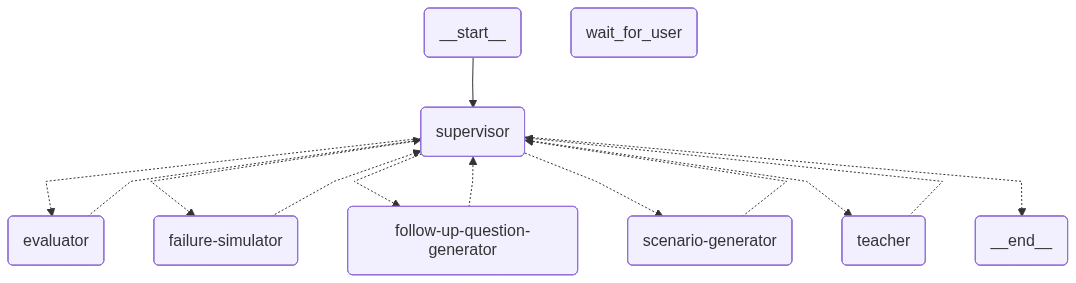

In [115]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [131]:
import pprint
import uuid
config = {
    "configurable": {
        "thread_id": uuid.uuid4()
    }
}

inputs = {
    "messages": [
        HumanMessage(
            content="topic: Load Balancer, Difficulty: easy "
        )
    ]
}

for event in app.stream(inputs, config=config):
    for key, value in event.items():
        if value is None:
            continue
        last_message = value.get("messages", [])[-1] if "messages" in value else None
        if last_message:
            pprint.pprint(f"Output from node '{key}':")
            pprint.pprint(last_message, indent=2, width=80, depth=None)
            print()

--- Workflow Transition: Supervisor → SCENARIO-GENERATOR ---
"Output from node 'supervisor':"
HumanMessage(content='The user has defined the topic and difficulty level, so the next logical step is to initiate the interview process by creating a specific, relevant scenario for them to solve.', additional_kwargs={}, response_metadata={}, name='supervisor', id='802b8a10-535a-4160-b4cf-7b281f915f8c')

--- Workflow Transition: Scenario Generator → Supervisor (Query Enhanced) ---
Enhanced Query: [{'type': 'text', 'text': '### Refined Specification: Load Balancer (Beginner Level)\n\n**Topic Context:** \nThe interview focus is on the fundamental concepts and basic architectural implementation of a Load Balancer (LB) in a distributed system. The goal is to evaluate the candidate\'s understanding of why load balancers are necessary, how they sit within a network architecture, and their primary role in distributing incoming traffic across a pool of backend servers.\n\n**Difficulty Interpretation 

In [111]:
for event in app.stream(
    Command(
        resume=".LQBJLWS EQ;JN"
    ),
    config=config,
):
    print(event)

{'wait_for_user': {'messages': [HumanMessage(content='.LQBJLWS EQ;JN', additional_kwargs={}, response_metadata={}, id='b8e9ad42-5c09-4c70-a936-f1741fee4919')]}}
--- Workflow Transition: Supervisor → EVALUATOR ---
{'supervisor': {'messages': [HumanMessage(content='The user has presented a solution. The next logical step is to have the evaluator review the response to provide feedback, scoring, and analysis of strengths and weaknesses before proceeding further.', additional_kwargs={}, response_metadata={}, name='supervisor', id='16358811-328b-4e8e-abd4-1dd5ff21e317')]}}
--- Workflow Transition: Evaluator → Supervisor ---
{'evaluator': None}
